# Phase 2 - Baseline Model Training

In [65]:
# Public Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import sys

# Custom Imports
src_dir = Path("../src")
sys.path.insert(0, str(src_dir))

from evaluate import *
from model import *
# from train import *

# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create models directory if it doesn't exist
models_dir = Path("../models")

# Define paths for data and models
data_dir = Path("../data/processed")

## Load Training and Test Data

In [ ]:
# Load train and test tables
train_data_path = data_dir / "train.csv"
test_data_path = data_dir / "test.csv"

train_set = pd.read_csv(train_data_path)
test_set = pd.read_csv(test_data_path)

print("Train Set:")
display(train_set.head())
print("Test Set:")
display(test_set.head())

# Convert labels to numeric classes expected by sklearn metrics
label_to_int = {"normal": 0, "anomaly": 1}

feature_cols = [c for c in train_set.columns if c not in ["label", "binary_label"]]
X_train_df = train_set[feature_cols]
X_test_df = test_set[feature_cols]

y_train_series = train_set["binary_label"].map(label_to_int)
y_test_series = test_set["binary_label"].map(label_to_int)

if y_train_series.isna().any() or y_test_series.isna().any():
    raise ValueError("Unexpected values found in binary_label. Expected only 'normal' and 'anomaly'.")

# Default source: arrays built from CSV
X_train = X_train_df.to_numpy(dtype=np.float32)
X_test = X_test_df.to_numpy(dtype=np.float32)
y_train = y_train_series.to_numpy(dtype=np.int32)
y_test = y_test_series.to_numpy(dtype=np.int32)
source = "CSV-derived arrays"


print(f"Train Set Shape: {X_train.shape}, Labels Shape: {y_train.shape}")
print(f"Test Set Shape: {X_test.shape}, Labels Shape: {y_test.shape}")

Train Set:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.026526,-0.092098,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
1,-0.145561,-0.026472,-0.051431,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
2,-0.145561,-0.026689,-0.086207,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
3,-0.145561,-0.026173,-0.066131,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
4,-0.145561,-0.025901,0.015446,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False


Test Set:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False
1,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False
2,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,True,False,False,False,False,False,False,False,False,False
3,-0.145561,-0.029163,-0.080533,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
4,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False


Using data source: pre-saved .npy arrays
Train X sample:


...

Test X sample:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.145561,-0.029163,-0.080533,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


Test y sample:


0    1
1    1
2    1
3    0
4    1
Name: y_test, dtype: int64

Train Set Shape: (61482, 118), Labels Shape: (61482,)
Test Set Shape: (84104, 118), Labels Shape: (84104,)


## Model Architecture Setup (2.1)

In [67]:
# Develop functions here (Finsihed function go into the .py files in the src folder)

In [68]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Sequential

class Autoencoder(tf.keras.Model):

    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.input_dim = int(input_dim)
        self.latent_dim = int(latent_dim)

        self.input_layer = layers.InputLayer(shape=(self.input_dim,))
        self.encoder = Sequential([
            layers.Dense(32, activation="relu"),
            layers.Dense(self.latent_dim, activation="relu")
        ])

        self.decoder = Sequential([
            layers.Dense(32, activation="relu"),
            layers.Dense(self.input_dim, activation="linear")
        ])

    def call(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

    # Keep config minimal and deterministic so model.save() works reliably.
    def get_config(self):
        config = super().get_config()
        config.update({
            "input_dim": self.input_dim,
            "latent_dim": self.latent_dim,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [69]:
# Initialize the model
model  = Autoencoder(input_dim = X_train.shape[1], latent_dim = 16)

## Train Tool Implementation (2.2)

In [70]:
# Develop functions here (Finsihed function go into the .py files in the src folder)

In [71]:
# Compile the model
model.compile(optimizer = 'adam', loss = 'mse')

# Train Model
history = model.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=256
)

# Save the model
print("Saving the model...")
model.save(models_dir / "autoencoder_baseline_model.keras")
print("Final model saved!")

Epoch 1/50


241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 503us/step - loss: 0.2180
Epoch 2/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - loss: 0.1257
Epoch 3/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - loss: 0.0947
Epoch 4/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - loss: 0.0797
Epoch 5/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - loss: 0.0718
Epoch 6/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - loss: 0.0669
Epoch 7/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - loss: 0.0627
Epoch 8/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - loss: 0.0589
Epoch 9/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - loss: 0.0545
Epoch 10/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0505  
Epoch 11/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - loss: 0.0468
Epoch 12/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0430
Epoch 13/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - loss: 0.0394
Epoch 14/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - loss: 0.0365
Epoch 15/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0

## Baseline Training & Anomaly Thresholding (2.3)

In [72]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Global Variables for model development
THRESHOLD_PERCENTILE = 95

def calculate_reconstruction_error(model, data):
    """Calculate reconstruction error (MSE) for each sample."""
    reconstructed_data = model.predict(data, verbose=0)
    return np.mean(np.square(data - reconstructed_data), axis=1)

def generate_anomaly_metrics_and_threshold(model, X_train, X_test, y_test, percentile=THRESHOLD_PERCENTILE):
    """
    Generate anomaly threshold and evaluation metrics with visualization.
    
    Parameters:
    - model: Trained autoencoder model
    - X_train: Training data (for threshold calibration)
    - X_test: Test data (for evaluation)
    - y_test: Test labels
    - percentile: Percentile for threshold determination
    
    Returns:
    - threshold: Calculated anomaly threshold
    - y_pred: Predicted anomaly labels for test set
    """
    # Calculate reconstruction errors (single pass)
    train_errors = calculate_reconstruction_error(model, X_train)
    test_errors = calculate_reconstruction_error(model, X_test)
    
    # Determine threshold from training data
    threshold = np.percentile(train_errors, percentile)
    print(f"Train set Anomaly Threshold (Percentile {percentile}): {threshold:.4f}\n")
    
    # Determine threshold from test data (optional, for comparison)
    # test_threshold = np.percentile(test_errors, percentile)
    # print(f"Test Set Threshold (Percentile {percentile}): {test_threshold:.4f}\n")
    
    # Predict anomalies for test set
    y_pred = np.where(test_errors > threshold, 1, 0)
    
    ####
    # Visualization 1: Reconstruction Error Distribution
    # plt.figure(figsize=(12, 5))
    
    # plt.subplot(1, 2, 1)
    # sns.histplot(train_errors, bins=50, kde=True, label='Training', alpha=0.7)
    # plt.axvline(threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold ({percentile}th %ile)')
    # plt.title('Reconstruction Error Distribution (Training Data)')
    # plt.xlabel('Reconstruction Error')
    # plt.ylabel('Frequency')
    # plt.legend()
    
    # Visualization 2: Test Set Anomaly Detection
    # plt.subplot(1, 2, 2)
    # colors = ['green' if pred == 0 else 'red' for pred in y_pred]
    # plt.scatter(range(len(test_errors)), test_errors, c=colors, alpha=0.6, s=30)
    # plt.axhline(threshold, color='r', linestyle='--', linewidth=2, label='Threshold')
    # plt.title('Test Set: Reconstruction Error vs Sample Index')
    # plt.xlabel('Sample Index')
    # plt.ylabel('Reconstruction Error')
    # plt.legend()
    
    # # plt.tight_layout()
    # plt.show()
    ####

    # Visualization 1: Reconstruction Error Distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(train_errors, bins=50, kde=True, label='Training', alpha=0.7)
    plt.axvline(threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold ({percentile}th %ile)')
    plt.title('Reconstruction Error Distribution (Training Data)')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Frequency')
    plt.legend()
    
    # Visualization 2: Test Set Anomaly Detection
    plt.subplot(1, 2, 2)
    colors = ['green' if pred == 0 else 'red' for pred in y_pred]
    plt.scatter(range(len(test_errors)), test_errors, c=colors, alpha=0.6, s=30)
    plt.axhline(threshold, color='r', linestyle='--', linewidth=2, label='Threshold')
    plt.title('Test Set: Reconstruction Error vs Sample Index')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.legend()
    
    # plt.tight_layout()
    plt.show()
    
    # Visualization 2: Test Set Anomaly Detection (with Log Scale)
    plt.subplot(1, 2, 2)
    colors = ['green' if pred == 0 else 'red' for pred in y_pred]
    plt.scatter(range(len(test_errors)), test_errors, c=colors, alpha=0.6, s=30)
    plt.axhline(threshold, color='r', linestyle='--', linewidth=2, label='Threshold')
    plt.yscale('log') # <--- Added to handle extreme error scales cleanly
    plt.title('Test Set: Reconstruction Error vs Sample Index (Log Scale)')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error (Log Scale)')
    plt.legend()
    
    plt.show()

    # Evaluation Metrics
    print("="*50)
    print("TEST SET EVALUATION METRICS")
    print("="*50)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


    return threshold, y_pred


A new final model has been trained in the notebook.


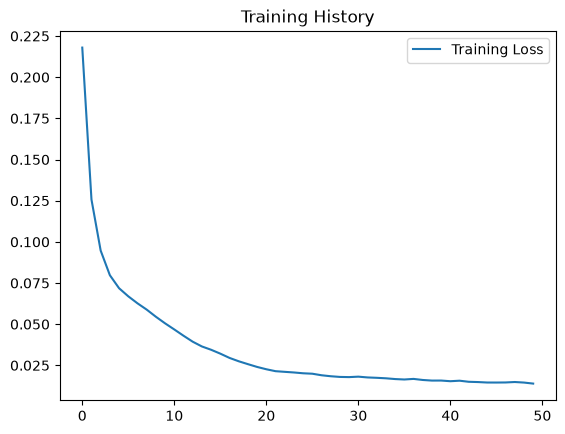


Final Model Summary:


Model: "autoencoder_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 118)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_12 (Sequential)      │ (None, 16)             │         4,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_13 (Sequential)      │ (None, 118)            │         4,438 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,324 (102.83 KB)

 Trainable params: 8,774 (34.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,550 (68.56 KB)

Generating anomaly metrics and threshold...

Train set Anomaly Threshold (Percentile 95): 0.0366



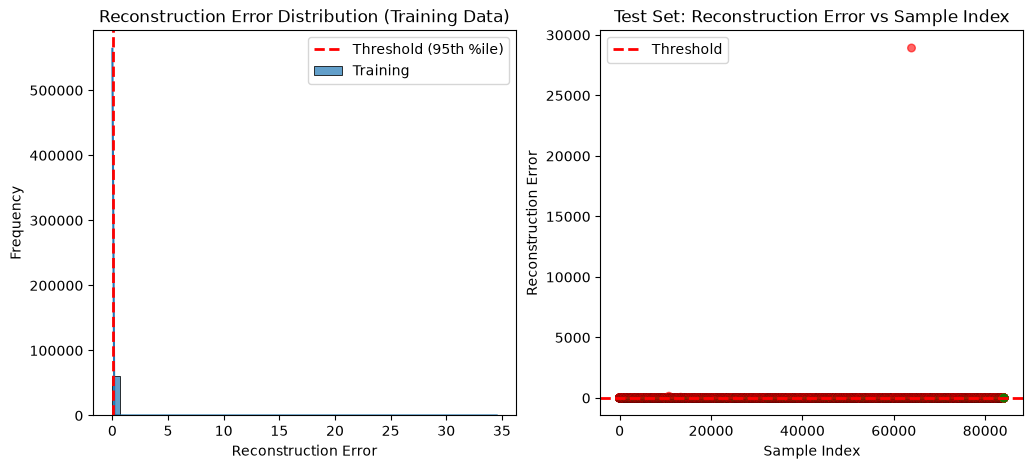

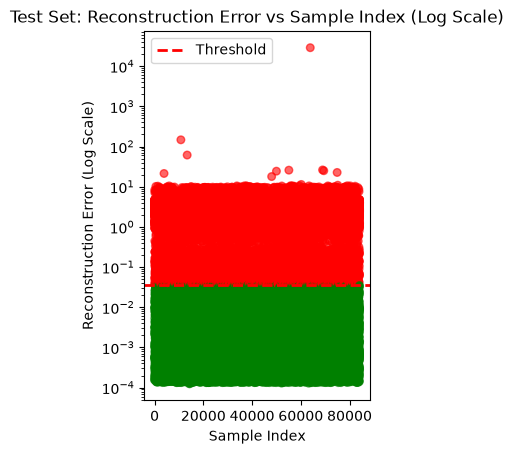

TEST SET EVALUATION METRICS
Accuracy: 0.9772

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     26350
           1       0.98      0.99      0.98     57754

    accuracy                           0.98     84104
   macro avg       0.98      0.97      0.97     84104
weighted avg       0.98      0.98      0.98     84104

Confusion Matrix:
[[24985  1365]
 [  554 57200]]


In [73]:
# Check if the final model has been trained in the notebook; otherwise load it from disk
if "model" not in locals() or model is None:
    print("Final model not found. Loading the best model from model directory...")
    model = keras.models.load_model("../models/autoencoder_baseline_model.keras")
else:
    print("A new final model has been trained in the notebook.")

# Plot available training history safely (if present)
if "history" in locals() and hasattr(history, "history"):
    if "loss" in history.history:
        plt.plot(history.history["loss"], label="Training Loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Training History")
    plt.legend()
    plt.show()

# Output the model summary for verification
print("\nFinal Model Summary:")
model.summary()

print("Generating anomaly metrics and threshold...\n")
threshold, y_pred = generate_anomaly_metrics_and_threshold(
    model, X_train, X_test, y_test, percentile=THRESHOLD_PERCENTILE
)